# Actividad 2: Calidad, Drift y Anomalías

## 1. Carga y preparación de datos

Usamos el mismo dataset de salarios en data science de la Actividad 1 y lo dividimos en dos períodos para el análisis de drift:
- **Referencia**: 2020-2021
- **Actual**: 2022-2023

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('data/ds_salaries.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 3755 filas, 11 columnas


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
df_ref = df[df['work_year'].isin([2020, 2021])].copy()
df_act = df[df['work_year'].isin([2022, 2023])].copy()

print(f"Período de referencia (2020-2021): {df_ref.shape[0]} registros ({df_ref.shape[0]/len(df):.1%} del total)")
print(f"Período actual (2022-2023)       : {df_act.shape[0]} registros ({df_act.shape[0]/len(df):.1%} del total)")

Período de referencia (2020-2021): 306 registros (8.1% del total)
Período actual (2022-2023)       : 3449 registros (91.9% del total)


El período de referencia representa una fracción muy chica del dataset. Esto ya es un primer indicio de que la composición de ambos períodos puede ser bastante distinta, más allá de la evolución real del mercado: la encuesta de origen recién ganó volumen de respuestas a partir de 2022.

## 2. Calidad y drift

### 2.1 Selección de variables y chequeos de calidad

Aplicamos 4 chequeos de calidad sobre el dataset completo.

In [4]:
vars_analisis = ['salary_in_usd', 'experience_level', 'remote_ratio', 'company_size']

# 1. Valores nulos
print("--- Valores nulos ---")
print(df[vars_analisis].isnull().sum())
print()

# 2. Registros duplicados (considerando todas las columnas del dataset)
n_dup = df.duplicated().sum()
print(f"--- Duplicados ---")
print(f"Registros duplicados: {n_dup} ({n_dup/len(df):.1%} del total)")
print()

# 3. Dominio de categorías válidas
dominios_validos = {
    'experience_level': {'EN', 'MI', 'SE', 'EX'},
    'company_size': {'S', 'M', 'L'},
    'remote_ratio': {0, 50, 100},
}
print("--- Valores fuera de dominio esperado ---")
for col, validos in dominios_validos.items():
    fuera = (~df[col].isin(validos)).sum()
    print(f"{col}: {fuera} valores fuera de {sorted(validos)}")
print()

# 4. Rango de salary_in_usd
print("--- Rango de salary_in_usd ---")
print(f"Valores <= 0: {(df['salary_in_usd'] <= 0).sum()}")
print(f"Mínimo: ${df['salary_in_usd'].min():,.0f} | Máximo: ${df['salary_in_usd'].max():,.0f}")

--- Valores nulos ---
salary_in_usd       0
experience_level    0
remote_ratio        0
company_size        0
dtype: int64

--- Duplicados ---
Registros duplicados: 1171 (31.2% del total)

--- Valores fuera de dominio esperado ---
experience_level: 0 valores fuera de ['EN', 'EX', 'MI', 'SE']
company_size: 0 valores fuera de ['L', 'M', 'S']
remote_ratio: 0 valores fuera de [0, 50, 100]

--- Rango de salary_in_usd ---
Valores <= 0: 0
Mínimo: $5,132 | Máximo: $450,000


No hay valores nulos ni categorías fuera de dominio, y `salary_in_usd` es siempre positivo, así que en cuanto a completitud y validez el dataset parece estar limpio.

El único hallazgo a señalar es la cantidad de registros duplicados (~31% del total). En un dataset con columnas mayormente categóricas de baja cardinalidad (nivel de experiencia, tipo de contrato, modalidad remota) es esperable que distintas personas compartan exactamente el mismo perfil, así que no necesariamente son errores de carga. 

### 2.2 Cálculo de PSI (Population Stability Index)

In [5]:
def psi_categorica(ref, act):
    categorias = sorted(set(ref.unique()) | set(act.unique()))
    ref_pct = ref.value_counts(normalize=True).reindex(categorias, fill_value=0).clip(lower=1e-6)
    act_pct = act.value_counts(normalize=True).reindex(categorias, fill_value=0).clip(lower=1e-6)
    psi = ((act_pct - ref_pct) * np.log(act_pct / ref_pct)).sum()
    tabla = pd.DataFrame({'ref_%': ref_pct, 'actual_%': act_pct})
    return psi, tabla

def psi_numerica(ref, act, bins=10):
    cortes = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    cortes[0], cortes[-1] = -np.inf, np.inf
    ref_binned = pd.cut(ref, bins=cortes)
    act_binned = pd.cut(act, bins=cortes)
    ref_pct = ref_binned.value_counts(normalize=True, sort=False).clip(lower=1e-6)
    act_pct = act_binned.value_counts(normalize=True, sort=False).clip(lower=1e-6)
    psi = ((act_pct - ref_pct) * np.log(act_pct / ref_pct)).sum()
    tabla = pd.DataFrame({'ref_%': ref_pct, 'actual_%': act_pct})
    return psi, tabla

In [6]:
resultados_psi = {}

for col in ['experience_level', 'company_size', 'remote_ratio']:
    psi, tabla = psi_categorica(df_ref[col], df_act[col])
    resultados_psi[col] = psi
    print(f"=== {col} (PSI = {psi:.4f}) ===")
    print(tabla)
    print()

=== experience_level (PSI = 0.7417) ===
                     ref_%  actual_%
experience_level                    
EN                0.254902  0.070165
EX                0.042484  0.029284
MI                0.405229  0.197449
SE                0.297386  0.703102

=== company_size (PSI = 2.1981) ===
                 ref_%  actual_%
company_size                    
L             0.529412  0.084662
M             0.235294  0.893302
S             0.235294  0.022035

=== remote_ratio (PSI = 1.1914) ===
                 ref_%  actual_%
remote_ratio                    
0             0.163399  0.543056
50            0.316993  0.026674
100           0.519608  0.430270



In [7]:
psi_salario, tabla_salario = psi_numerica(df_ref['salary_in_usd'], df_act['salary_in_usd'])
resultados_psi['salary_in_usd'] = psi_salario

print(f"=== salary_in_usd (PSI = {psi_salario:.4f}) ===")
print(tabla_salario)

=== salary_in_usd (PSI = 0.8701) ===
                         ref_%  actual_%
salary_in_usd                           
(-inf, 19341.0]       0.101307  0.011308
(19341.0, 36643.0]    0.101307  0.013627
(36643.0, 50090.0]    0.098039  0.031603
(50090.0, 63831.0]    0.104575  0.040012
(63831.0, 79833.0]    0.098039  0.053929
(79833.0, 93150.0]    0.098039  0.058568
(93150.0, 110906.0]   0.098039  0.110757
(110906.0, 141846.0]  0.101307  0.216295
(141846.0, 185000.0]  0.101307  0.246448
(185000.0, inf]       0.098039  0.217454


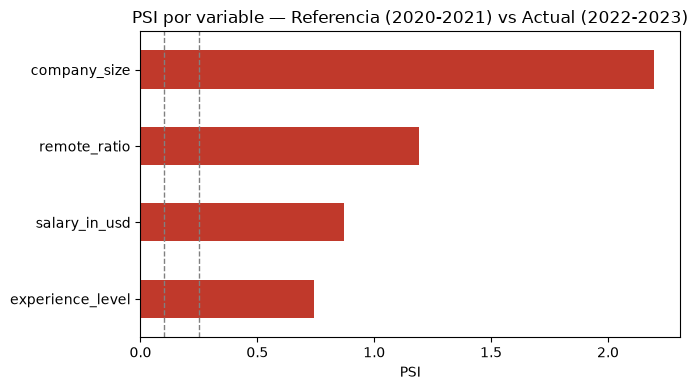

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
serie_psi = pd.Series(resultados_psi).sort_values()
colores = ['#c0392b' if v >= 0.25 else '#e67e22' if v >= 0.1 else '#27ae60' for v in serie_psi]
serie_psi.plot.barh(ax=ax, color=colores)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=1)
ax.axvline(0.25, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('PSI')
ax.set_title('PSI por variable — Referencia (2020-2021) vs Actual (2022-2023)')
plt.tight_layout()
plt.show()

### 2.3 Interpretación del drift

Usamos el umbral estándar de PSI: **< 0.1** sin drift relevante, **0.1 - 0.25** drift moderado, **> 0.25** drift significativo.

Las 4 variables quedan muy por encima de 0.25, así que en las 4 hay drift significativo:

- **`company_size`** es la que más cambia (PSI ≈ 2.20). En 2020-2021 predominaban empresas grandes y chicas en proporciones similares; en 2022-2023, casi 9 de cada 10 registros corresponden a empresas medianas. Es **covariate drift** (cambio en la distribución de una variable de entrada); probablemente asociado más a un sesgo de muestreo de la encuesta (quién responde) que a un cambio real en el mercado.

- **`remote_ratio`** también muestra un drift muy fuerte (PSI ≈ 1.19): en referencia predominaba el 100% remoto (pico pandemia), mientras que en el período actual crece fuertemente la modalidad presencial. Es **covariate drift**, pero a diferencia del anterior corresponde a un fenómeno real y documentado (retorno gradual a la oficina pospandemia), no solo a un sesgo de muestreo.

- **`experience_level`** (PSI ≈ 0.74): en referencia predominaban perfiles junior/mid, en el período actual predomina claramente el nivel senior. También es **covariate drift**, coherente con la maduración del campo (encuestados con más trayectoria a medida que pasa el tiempo).

- **`salary_in_usd`** (PSI ≈ 0.87): a diferencia de las anteriores, esta variable fue el *target* del modelo entrenado en la en el notebook anterior. El drift acá no es sobre un feature de entrada sino sobre la variable a predecir, por lo que corresponde más a un corrimiento de la distribución de la etiqueta. Como además 3 de las variables predictoras del modelo mostraron covariate drift fuerte, es razonable sospechar que también cambió la relación entre esas variables y el salario (**concept drift**), y no solo su distribución marginal.

### 2.4 Estrategia frente al drift (modelo de la Actividad 1)

El modelo final de la Actividad 1 (`RandomForestRegressor` sin `salary` como feature, entrenado con `experience_level`, `employment_type`, `job_title`, `salary_currency`, `employee_residence`, `company_location`, `company_size`, `work_year` y `remote_ratio`) se entrenó con un único split aleatorio sobre todo el dataset 2020-2023 mezclado.

Dado el nivel de drift detectado, la estrategia más adecuada es el **reentrenamiento periódico con datos recientes**, por sobre feature engineering o un ensamble:

- El *feature engineering* no ataca el problema de fondo acá: el drift no viene de una mala representación de las variables, sino de un cambio real en la composición del mercado (más seniority, menos remoto, otro perfil de tamaño de empresa).
- Un *ensamble* que combine un modelo "viejo" y uno "nuevo" tiene sentido cuando se espera que los regímenes convivan o alternen. Acá el fenómeno (retorno a oficina, maduración de roles, inflación salarial) es una tendencia sostenida en el tiempo, no algo cíclico, así que ponderar el pasado no aporta demasiado.
- Reentrenar con una ventana de datos más reciente, y repetir ese reentrenamiento de forma periódica a medida que se acumulan nuevos datos, es lo que mejor captura el mercado laboral vigente en vez de forzar a un único modelo estático a generalizar sobre dos regímenes bastante distintos.

## 3. Detección de anomalías

### 3.1 Preparación de variables

Usamos las mismas 4 variables del punto anterior, codificando las categóricas de forma ordinal y estandarizando todo para que ninguna domine por escala.

Sumamos además un jitter mínimo (ruido gaussiano de desvío 0.05) a las variables discretas: al tener pocos valores posibles, muchos registros comparten exactamente el mismo vector de features, y eso degrada el cálculo de densidad local de LOF (la distancia a los vecinos más próximos se va a 0 para muchos puntos a la vez).

In [9]:
exp_map = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
size_map = {'S': 0, 'M': 1, 'L': 2}

df['experience_level_enc'] = df['experience_level'].map(exp_map)
df['company_size_enc'] = df['company_size'].map(size_map)

feats = ['salary_in_usd', 'remote_ratio', 'experience_level_enc', 'company_size_enc']
X = df[feats].astype(float).copy()

rng = np.random.default_rng(RANDOM_STATE)
for col in ['remote_ratio', 'experience_level_enc', 'company_size_enc']:
    X[col] = X[col] + rng.normal(0, 0.05, size=len(X))

X_scaled = StandardScaler().fit_transform(X)
print(f"Features utilizadas: {feats}")

Features utilizadas: ['salary_in_usd', 'remote_ratio', 'experience_level_enc', 'company_size_enc']


### 3.2 Isolation Forest y LOF

In [10]:
iso_forest = IsolationForest(n_estimators=200, contamination=0.02, random_state=RANDOM_STATE)
df['iso_pred'] = iso_forest.fit_predict(X_scaled)
df['iso_score'] = iso_forest.decision_function(X_scaled)

lof = LocalOutlierFactor(n_neighbors=30, contamination=0.02)
df['lof_pred'] = lof.fit_predict(X_scaled)
df['lof_score'] = lof.negative_outlier_factor_

print(f"Anomalías detectadas por Isolation Forest: {(df['iso_pred'] == -1).sum()}")
print(f"Anomalías detectadas por LOF              : {(df['lof_pred'] == -1).sum()}")
print(f"Coinciden ambos métodos                   : {((df['iso_pred'] == -1) & (df['lof_pred'] == -1)).sum()}")

Anomalías detectadas por Isolation Forest: 76
Anomalías detectadas por LOF              : 76
Coinciden ambos métodos                   : 10


### 3.3 Registro anómalo destacado

In [11]:
cols_ver = ['work_year', 'job_title', 'experience_level', 'employment_type', 'salary_in_usd',
            'remote_ratio', 'company_size', 'iso_score', 'lof_score']

registro = df.loc[3675]
pct_global = (df['salary_in_usd'] < registro['salary_in_usd']).mean()
pct_dentro_S = (df[df['company_size'] == 'S']['salary_in_usd'] < registro['salary_in_usd']).mean()

print(registro[cols_ver])
print()
print(f"Percentil global de salary_in_usd: {pct_global:.2%}")
print(f"Percentil de salary_in_usd dentro de company_size='S': {pct_dentro_S:.2%}")
print()
print("Estadísticas de salary_in_usd en empresas chicas (company_size='S'):")
print(df[df['company_size'] == 'S']['salary_in_usd'].describe())

work_year                               2021
job_title           Principal Data Scientist
experience_level                          EX
employment_type                           CT
salary_in_usd                         416000
remote_ratio                             100
company_size                               S
iso_score                          -0.085217
lof_score                          -3.428187
Name: 3675, dtype: object

Percentil global de salary_in_usd: 99.87%
Percentil de salary_in_usd dentro de company_size='S': 99.32%

Estadísticas de salary_in_usd en empresas chicas (company_size='S'):
count       148.000000
mean      78226.682432
std       61955.141792
min        5679.000000
25%       35668.000000
50%       62146.000000
75%      107481.750000
max      416000.000000
Name: salary_in_usd, dtype: float64


El registro 3675 es un *Principal Data Scientist* (nivel EX), contratado (`CT`), 100% remoto, en una empresa chica (`company_size='S'`), con un salario de \$416.000. Está marcado como anómalo tanto por Isolation Forest como por LOF.

**Es un outlier univariado**: por sí solo, `salary_in_usd` = \$416.000 se ubica en el percentil 99.87% de todo el dataset, muy por encima de la media (~\$137.570) y de la mediana (~\$135.000).

**También es un outlier multivariado**: dentro del subconjunto de empresas chicas, este registro es el valor máximo absoluto, muy por encima del percentil 75 condicional (~\$107.500) y de la mediana condicional (~\$62.150) de ese subgrupo. Un salario ejecutivo tan alto ya es infrecuente en general, pero lo es todavía más combinado con una empresa chica, porque en este dataset los salarios más altos tienden a concentrarse en empresas medianas o grandes. Es justamente esa combinación -salario muy alto + empresa chica + modalidad contractual `CT`- la que hace que ambos métodos lo aíslen con tanta facilidad.

### 3.4 ¿Coinciden Isolation Forest y LOF?

In [12]:
solo_if = df[(df['iso_pred'] == -1) & (df['lof_pred'] == 1)].sort_values('iso_score').head(3)
solo_lof = df[(df['iso_pred'] == 1) & (df['lof_pred'] == -1)].sort_values('lof_score').head(3)

print("--- Marcados solo por Isolation Forest ---")
print(solo_if[cols_ver])
print()
print("--- Marcados solo por LOF ---")
print(solo_lof[cols_ver])

--- Marcados solo por Isolation Forest ---
      work_year                           job_title experience_level  \
3747       2021  Applied Machine Learning Scientist               MI   
1512       2023                      Data Scientist               EN   
83         2022                        AI Developer               EN   

     employment_type  salary_in_usd  remote_ratio company_size  iso_score  \
3747              FT         423000            50            L  -0.054730   
1512              FT          12888            50            S  -0.048331   
83                FT         300000            50            L  -0.044867   

      lof_score  
3747  -2.032727  
1512  -1.048689  
83    -1.953496  

--- Marcados solo por LOF ---
      work_year          job_title experience_level employment_type  \
323        2022       AI Developer               SE              FT   
2651       2022  Big Data Engineer               SE              FT   
3613       2020  Big Data Engineer         

De las 76 anomalías que detecta cada método, solo 10 coinciden entre ambos. Tiene sentido, porque parten de lógicas distintas:

- **Isolation Forest** aísla observaciones mediante particiones aleatorias del espacio de features: una observación es anómala si alcanza con pocas divisiones para separarla del resto, sin importar en qué región del espacio esté. Por eso tiende a marcar valores extremos a nivel **global** (salarios muy altos o muy bajos en términos absolutos).

- **LOF** compara la densidad local de cada punto contra la de sus vecinos más cercanos. Un punto puede no ser extremo en términos globales, pero si su entorno inmediato es mucho más denso que él, LOF lo marca igual. Por eso detecta anomalías **locales**: valores que se destacan dentro de un subgrupo puntual aunque no sean records extremos del dataset completo.

Un buen ejemplo de esta diferencia es el registro marcado solo por LOF (`AI Developer`, SE, \$275.000, presencial, empresa chica): su salario está en el percentil ~97% a nivel global, alto pero no tan extremo como el caso anterior (que estaba en el percentil ~99.9%), por lo que a Isolation Forest le cuesta más aislarlo con pocas particiones. Sin embargo, dentro de su entorno local -perfiles de nivel de experiencia y tamaño de empresa similares, con salarios bastante más bajos- se destaca con claridad, y eso es lo que dispara su score de LOF.

En el otro sentido, el registro marcado solo por Isolation Forest (`Applied Machine Learning Scientist`, MI, \$423.000, empresa grande) tiene un salario extremo a nivel global (percentil ~99.9%) que se aísla con pocas particiones. Pero al pertenecer a una empresa grande, donde también existen otros salarios altos, su densidad local no resulta tan atípica frente a sus vecinos, y LOF no llega a superar el umbral de contaminación fijado.

## 4. Conclusiones

- Las 4 variables analizadas muestran drift significativo (PSI > 0.25) entre 2020-2021 y 2022-2023. En `experience_level`, `remote_ratio` y `company_size` es drift de tipo covariate (cambia la distribución de los features de entrada); en `salary_in_usd`, al ser el target del modelo de la Actividad 1, el corrimiento sugiere además concept drift.
- Frente a ese drift, la estrategia más razonable para el modelo de la Actividad 1 es reentrenar periódicamente con datos recientes, ya que el cambio responde a tendencias sostenidas del mercado (retorno a oficina, maduración de roles) y no a alternancia entre regímenes ni a una mala representación de las variables.
- Isolation Forest y LOF coinciden en muy pocos casos (10 de 76 cada uno) porque miden anomalía de forma distinta: uno aísla valores extremos globales, el otro compara densidad local. Combinar ambos da una visión más completa que usar uno solo: captura tanto los outliers "raros en todo el dataset" como los "raros dentro de su propio grupo".